In [1]:
import elecboltz
from cuprates_transport.bandstructure import BandStructure
from cuprates_transport.conductivity import Conductivity

from time import time
from scipy.constants import e, m_e, hbar, electron_volt
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt

In [ ]:
# matplotlib settings
# reset defaults
mpl.rcdefaults()
# font
mpl.rcParams['font.size'] = 24
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = 'CMU Serif'
mpl.rcParams['mathtext.fontset'] = 'cm'
mpl.rcParams['legend.fontsize'] = 'small'
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['xtick.top'] = True
mpl.rcParams['ytick.right'] = True
mpl.rcParams['xtick.major.width'] = 1.0
mpl.rcParams['ytick.major.width'] = 1.0
mpl.rcParams['pdf.fonttype'] = 3
# plotting
mpl.rcParams['figure.figsize'] = (8, 6)
mpl.rcParams['lines.linewidth'] = 3
mpl.rcParams['lines.markersize'] = 20

In [3]:
params_chambers = {
    "band_name": "PdCrO2",
    "a": 2.94,
    "b": 2.94,
    "c": 18.06,
    "energy_scale": -789,
    "band_params": {
        "mu": -0.22,
        "t": 1,
        "tp": -0.23,
        "tz": 0.03
    },
    "resolution": [
        30,
        30,
        30
    ],
    "k_max": [
        3.141592653589793,
        3.141592653589793,
        9.42477796076938
    ],
    "number_of_bz": 0.8660254037844386,
    "band_model": "mu + t*(2*cos(sqrt(3)/2*a*kx)*cos(1/2*b*ky) + cos(b*ky)) + tp*(2*cos(sqrt(3)/2*a*kx)*cos(3/2*b*ky) + cos(sqrt(3)*a*kx)) + tz*(cos(sqrt(3)*a*kx/3+c*kz/3) + cos(-sqrt(3)*a*kx/6+a*ky/2+c*kz/3) + cos(-sqrt(3)*a*kx/6-a*ky/2+c*kz/3))",
    "Bamp": 41.5,
    "Btheta_min": 70,
    "Btheta_max": 210,
    "Btheta_norm": 180,
    "Btheta_step": 2,
    "Bphi_array": [
        0,
        30,
        45,
        60
    ],
    "T": 0,
    "N_time": 5000,
    "scattering_models": [
        "isotropic",
        "cos3phi"
    ],
    "scattering_params": {
        "gamma_0": 3.801549281639093,
        "gamma_k": 1.6069878606666017,
        "power": 27.219573074498236
    },
    "march_square": True
}

In [4]:
params_fem = params_chambers.copy()
params_fem['dispersion'] = params_chambers['band_model']
params_fem['resolution'] = 41
params_fem['domain_size'] = [1.0, 1.0, 3.0]
params_fem['periodic'] = True
params_fem = elecboltz.easy_params(params_fem)

In [5]:
band_chambers = BandStructure(**params_chambers)
band_chambers.runBandStructure()
band_fem = elecboltz.BandStructure(**params_fem)
band_fem.discretize()

In [6]:
band_chambers.mass_func()
band_chambers.mass

np.float64(1.6053817271695312)

In [7]:
band_fem.calculate_mass()

np.float64(1.6097079735300863)

In [ ]:
# Chambers only
field_mag = 41.5
field_phi = np.array([0, np.pi / 6, np.pi / 4, np.pi / 3])
field_theta_deg = np.linspace(70, 210, 100)
field_theta_rad = np.deg2rad(field_theta_deg)
rho_chambers_zz = np.empty((len(field_phi), len(field_theta_rad)))
params_chambers['Bamp'] = field_mag
time_start = time()
for i, phi in enumerate(field_phi):
    params_chambers['Bphi'] = phi * 180 / np.pi
    for j, theta in enumerate(field_theta_rad):
        params_chambers['Btheta'] = theta * 180 / np.pi
        cond_chambers = Conductivity(band_chambers, **params_chambers)
        cond_chambers.runTransport()
        rho_chambers = np.linalg.inv(cond_chambers.sigma)
        rho_chambers_zz[i, j] = rho_chambers[2, 2]
normal_rho_chambers_zz = np.empty_like(field_phi)
params_chambers['Btheta'] = params_chambers['Btheta_norm']
for i, phi in enumerate(field_phi):
    cond_chambers = Conductivity(band_chambers, **params_chambers)
    cond_chambers.runTransport()
    rho_chambers = np.linalg.inv(cond_chambers.sigma)
    normal_rho_chambers_zz[i] = rho_chambers[2, 2]
time_end = time()
time_chambers = time_end - time_start

In [ ]:
# FEM only
field_mag = 41.5
field_phi = np.array([0, np.pi / 6, np.pi / 4, np.pi / 3])
field_theta_deg = np.linspace(70, 210, 100)
field_theta_rad = np.deg2rad(field_theta_deg)
rho_fem_zz = np.empty((len(field_phi), len(field_theta_rad)))
cond_fem = elecboltz.Conductivity(band_fem, **params_fem)
time_start = time()
for i, phi in enumerate(field_phi):
    for j, theta in enumerate(field_theta_rad):
        cond_fem.field = field_mag * np.array([
            np.sin(theta) * np.cos(phi), np.sin(theta) * np.sin(phi),
            np.cos(theta)])
        cond_fem.calculate()
        rho_fem = np.linalg.inv(cond_fem.sigma
                                / params_chambers['number_of_bz'])
        rho_fem_zz[i, j] = rho_fem[2, 2]
normal_rho_fem_zz = np.empty_like(field_phi)
theta = params_fem['Btheta_norm'] * np.pi / 180
for i, phi in enumerate(field_phi):
    cond_fem.field = field_mag * np.array([
        np.sin(theta) * np.cos(phi), np.sin(theta) * np.sin(phi),
        np.cos(theta)])
    cond_fem.calculate()
    rho_fem = np.linalg.inv(cond_fem.sigma
                            / params_chambers['number_of_bz'])
    normal_rho_fem_zz[i] = rho_fem[2, 2]
time_end = time()
time_fem = time_end - time_start

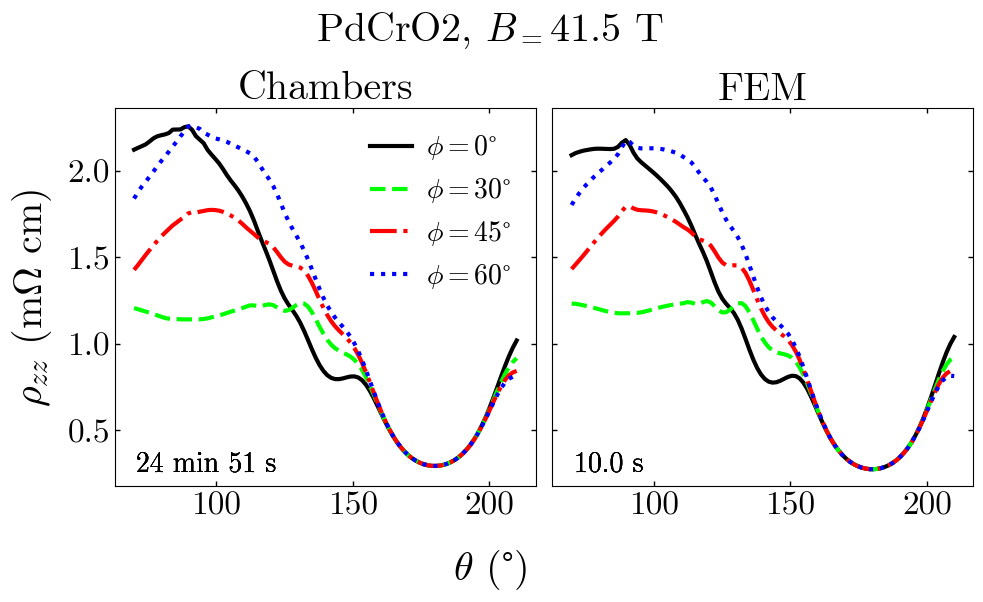

In [ ]:
fig, axs = plt.subplots(1, 2, figsize = (10, 6),
                        sharex=True, sharey=True)
palette = ['black', 'lime', 'red', 'blue']
styles = ['-', '--', '-.', ':']
# [mpl.cm.viridis(i / (len(field_phi) - 1)) for i in range(len(field_phi))]
for i, phi in enumerate(np.rad2deg(field_phi)):
    phi = int(round(phi))
    color = palette[i]
    axs[0].plot(field_theta_deg, 1e5 * rho_chambers_zz[i, :],
                label=rf"$\phi={phi}$°", color=palette[i],
                linestyle=styles[i])
    axs[1].plot(field_theta_deg, 1e5 * rho_fem_zz[i, :], color=palette[i],
                linestyle=styles[i])
axs[0].text(0.05, 0.04, f"{int(time_chambers // 60)} min " +
            f"{int(round(time_chambers % 60))} s", fontsize=20,
            ha='left', transform=axs[0].transAxes)
axs[1].text(0.05, 0.04, f"{time_fem:.1f} s", fontsize=20,
            ha='left', transform=axs[1].transAxes)
fig.suptitle(fr"PdCrO2, $B={field_mag}$ T")
axs[0].set_title("Chambers")
axs[1].set_title("FEM")
fig.supxlabel(r"$\theta$ (°)", )
fig.supylabel(r"$\rho_{zz}$ (m$\Omega$ cm)")
axs[0].legend(frameon=False, handlelength=1.5, handletextpad=0.5)
plt.tight_layout(pad=0.5)
plt.savefig("ADMR_PdCrO2_chambers_vs_fem.pdf", bbox_inches='tight')
plt.show()

In [ ]:
fields = np.linspace(1, 100, 100)
rh_chambers = np.empty_like(fields)
rh_fem = np.empty_like(fields)
cond_fem = elecboltz.Conductivity(band_fem, **params_fem)
for i, field in enumerate(fields):
    params_chambers['Bamp'] = field
    cond_chambers = Conductivity(band_chambers, **params_chambers)
    cond_fem.field = [0, 0, field]
    cond_chambers.runTransport()
    # rh_chambers[i] = cond_chambers.sigma[0, 1] / field / (
    #     cond_chambers.sigma[0, 0]**2 + cond_chambers.sigma[0, 1]**2)
    rh_chambers[i] = -np.linalg.inv(cond_chambers.sigma)[0, 1] / field
    cond_fem.calculate()
    # rh_fem[i] = cond_fem.sigma[0, 1] / field / (
    #     cond_fem.sigma[0, 0]**2 + cond_fem.sigma[0, 1]**2)
    rh_fem[i] = -np.linalg.inv(
        cond_fem.sigma / params_chambers['number_of_bz'])[0, 1] / field
n = band_fem.calculate_electron_density()
rh_inf = -params_chambers['number_of_bz'] / n / e

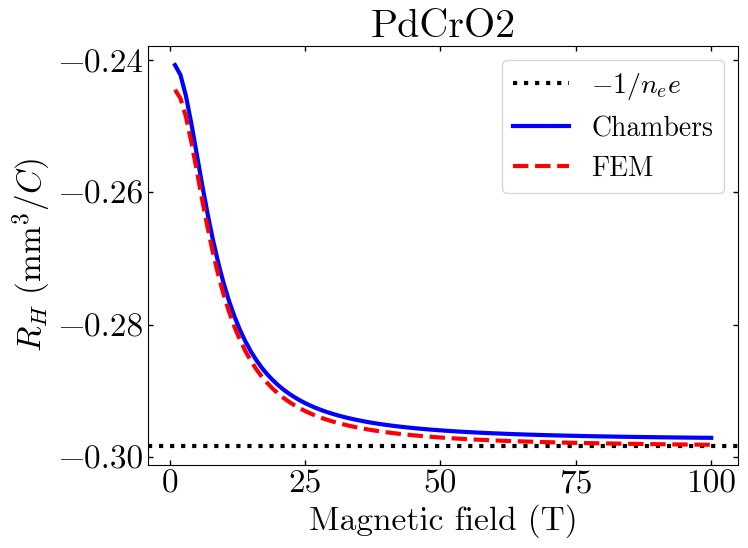

In [ ]:
plt.axhline(1e9 * rh_inf, color='black', linestyle=':', label=r"$-1/n_ee$")
plt.plot(fields, 1e9 * rh_chambers, label="Chambers", color='blue')
plt.plot(fields, 1e9 * rh_fem, label="FEM", color='red', linestyle='--')
plt.xlabel("Magnetic field (T)")
plt.ylabel(r"$R_H$ ($\mathrm{mm}^3/C$)")
plt.title("PdCrO2")
plt.legend()
plt.tight_layout()
plt.savefig("RH_PdCrO2_fem_vs_chambers.pdf", bbox_inches='tight')
plt.show()